## Notebook 3: Hazard and Exposure 

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [14]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [15]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [16]:
cfg  = C.get("cfg")     # dict loaded from YAML

In [17]:
age_npz = INT / f"age_on_ref_{SLUG}.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"

needed_nb2 = [
    INT / "template_ref.tif",
    INT / "city_mask.tif",
    age_npz,
    pop_npz,
    OUT / f"{SLUG}_fua.gpkg",
    INT / "hazard_manifest.json",
]

missing = [p for p in needed_nb2 if not p.exists()]
if missing:
    raise FileNotFoundError("Re-run Notebook 2. Missing:\n" + "\n".join(map(str, missing)))

**Imports**

In [18]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.transform import array_bounds

from climada.hazard import Hazard, Centroids
from scipy import sparse

plt.rcParams.update({"figure.dpi": 130})

In [19]:
from pathlib import Path
import json, numpy as np, rasterio as rio
import geopandas as gpd

# meta/georef, city mask, age/pop rasters on WBGT grid, FUA, hazard manifest
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
mask_npz  = INT / "city_mask.npz"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"
manifest  = INT / "hazard_manifest.json"
exp_meta  = INT / "exposure_meta.json"

age_npz_candidates = [INT / f"age_on_ref_{SLUG}.npz", INT / "age_on_ref.npz"]
pop_npz_candidates = [INT / f"pop_on_ref_{SLUG}.npz", INT / "pop_on_ref.npz"]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]  

age_npz = first_existing(age_npz_candidates)
pop_npz = first_existing(pop_npz_candidates)

# Template meta
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

# CITY_MASK
if mask_tif.exists():
    with rio.open(mask_tif) as src:
        CITY_MASK = src.read(1).astype(bool)
elif mask_npz.exists():
    CITY_MASK = np.load(mask_npz)["city_mask"].astype(bool)
else:
    raise FileNotFoundError("city_mask.tif/npz not found. Re-run Notebook 2.")

assert CITY_MASK.shape == (HGT, WDT)
ref_data = np.where(CITY_MASK, 0.0, np.nan)

# Age/pop rasters on WBGT grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# metadata for exposures
try:
    year = int(json.load(open(exp_meta))["worldpop_year"])
except Exception:
    year = 2030

# FUA geometry
if not fua_gp.exists():
    raise FileNotFoundError(f"{fua_gp.name} not found. Re-run Notebook 2 to save FUA.")
fua = gpd.read_file(fua_gp, layer="fua")
if fua.empty:
    raise ValueError("FUA is empty.")

# Hazard manifest
man = json.load(open(manifest))
years = [int(y) for y in man["years"]]
from pathlib import Path as _P
tif_paths = {int(y): _P(p) for y, p in man["files"].items()}

print(f"Loaded years: {years}")
print(f"Mask true pixels: {CITY_MASK.sum():,}")
print("WBGT grid shape:", (HGT, WDT))

Loaded years: [2030, 2050, 2070, 2090, 2100]
Mask true pixels: 24,823
WBGT grid shape: (191, 291)


**Helpers**

In [20]:
def read_and_mask_to_fua(raster_path: Path, fua_gdf: gpd.GeoDataFrame):
    with rio.open(raster_path) as src:
        fua_in_raster_crs = fua_gdf.to_crs(src.crs)
        geoms = [g for g in fua_in_raster_crs.geometry if g is not None]
        out, out_transform = rio_mask(src, geoms, crop=True, filled=True, nodata=np.nan)
        meta = src.meta.copy()
        meta.update(height=out.shape[1], width=out.shape[2], transform=out_transform)
        return out[0].astype(float), out_transform, src.crs, meta

def ensure_on_reference_grid_bilinear(src_path: Path, ref_meta, ref_data_shape, fua_gdf: gpd.GeoDataFrame):
    src_data, _, _, src_meta = read_and_mask_to_fua(src_path, fua_gdf)
    same_grid = (
        (src_meta["crs"] == ref_meta["crs"]) and
        (src_meta["transform"] == ref_meta["transform"]) and
        (src_data.shape == ref_data_shape)
    )
    if same_grid:
        return src_data, ref_meta
    dst = np.full(ref_data_shape, np.nan, dtype=float)
    reproject(
        source=src_data,
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst, ref_meta

In [21]:
wbgt_hot_days = {}
for y in years:
    arr, _ = ensure_on_reference_grid_bilinear(tif_paths[y], ref_meta, (HGT, WDT), fua)
    # keep only inside the city footprint for plotting; values outside will be NaN
    arr = np.where(CITY_MASK, arr, np.nan)
    wbgt_hot_days[y] = arr
    v = arr[np.isfinite(arr)]
    print(f"{y}: min={np.nanmin(v):.1f}, median={np.nanmedian(v):.1f}, 95p={np.nanpercentile(v,95):.1f}, max={np.nanmax(v):.1f}")

2030: min=0.0, median=0.7, 95p=2.9, max=3.8
2050: min=0.0, median=2.8, 95p=8.2, max=10.3
2070: min=0.0, median=6.8, 95p=17.1, max=18.8
2090: min=0.0, median=13.6, 95p=25.5, max=28.5
2100: min=0.0, median=15.7, 95p=29.4, max=32.4


## Hazard

In [22]:
# Centroids: exact centers of WBGT cells (after FUA clip/resample)
rows, cols = np.indices((HGT, WDT))
xs, ys = rio.transform.xy(ref_meta["transform"], rows, cols, offset="center")
lon = np.asarray(xs, dtype=float).ravel()
lat = np.asarray(ys, dtype=float).ravel()

# Intensity matrix: events x cells (NaN→0 for sparse)
I_dense = np.stack([np.nan_to_num(wbgt_hot_days[y].ravel(), nan=0.0).astype("float32") for y in years], axis=0)
I = sparse.csr_matrix(I_dense)

# Footprint (0/1): where intensity > 0
F = sparse.csr_matrix((I_dense > 0).astype(float))

Ctd = Centroids(lat=lat, lon=lon)

H = Hazard("HEAT")
H.haz_type   = "HEAT"
H.units      = "hot-days/year (WBGT>28°C)"
H.orig    = np.array([f"{CITY}_UrbClim_WBGT28d"] * len(years), dtype=object)
H.event_id   = np.array(years, dtype=int)
H.event_name = np.array([f"HEAT_{y}" for y in years])
H.date       = np.array([np.datetime64(f"{y}-07-01") for y in years])
H.frequency  = np.ones(len(years), dtype=float)
H.centroids  = Ctd
H.intensity  = I
H.fraction   = F

H.check()
print(H)

**plots**

Events in H (row order): [2030 2050 2070 2090 2100]


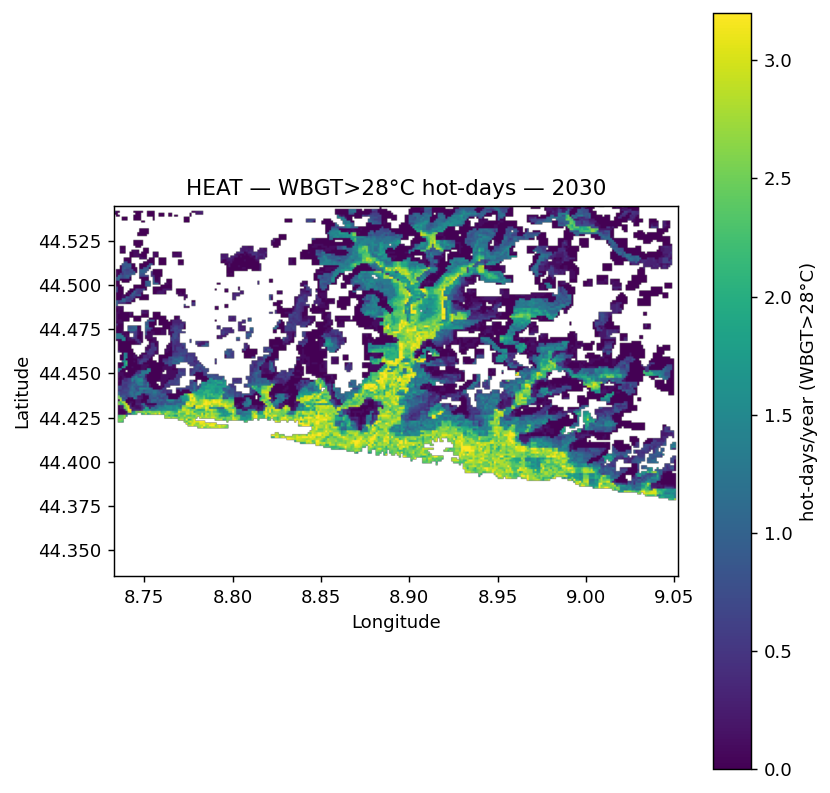

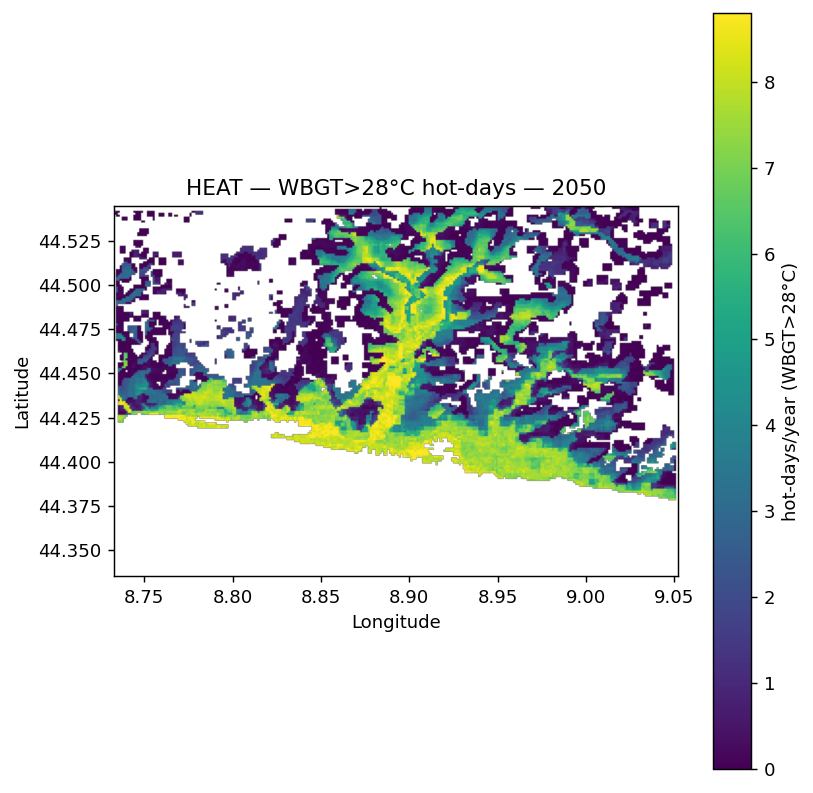

In [23]:
T = ref_meta["transform"]
left, bottom, right, top = array_bounds(HGT, WDT, T)
extent = (left, right, bottom, top)

ids = np.asarray(H.event_id).astype(int)
year2row = {int(e): i for i, e in enumerate(ids)}
print("Events in H (row order):", ids)

def plot_hazard_year(H, year, shape, extent):
    idx = year2row.get(int(year))
    if idx is None:
        raise KeyError(f"Year {year} not in H.event_id")
    arr = H.intensity.getrow(idx).toarray().reshape(shape)
    m = np.ma.masked_where(~CITY_MASK, arr)
    vmax = np.nanpercentile(arr[CITY_MASK], 99) if CITY_MASK.any() else None

    plt.figure(figsize=(6.5, 6.2))
    im = plt.imshow(m, origin="upper", extent=extent, vmin=0, vmax=vmax)
    cb = plt.colorbar(im); cb.set_label(H.units)
    plt.title(f"{H.haz_type} — WBGT>28°C hot-days — {year}")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.tight_layout(); plt.show()

plot_hazard_year(H, years[0], (HGT, WDT), extent)
plot_hazard_year(H, years[1], (HGT, WDT), extent)

## Exposure on same centroids 

**Aggregating Worldpop to grid**

description: None
ref_year: 2030
value_unit: people
crs: EPSG:4326
data: (74469 entries)
          value age_group  impf_HEAT                  geometry
0      0.210637       <15          1  POINT (8.99336 44.54418)
1      0.122708       <15          1  POINT (8.99446 44.54418)
2      0.137117       <15          1  POINT (8.99555 44.54418)
3      0.117362       <15          1  POINT (8.99665 44.54418)
74465  0.003672       65+          3  POINT (9.04708 44.37862)
74466  0.009701       65+          3  POINT (9.04818 44.37862)
74467  0.001995       65+          3  POINT (9.04928 44.37862)
74468  0.000615       65+          3  POINT (9.05037 44.37862)
Total people in exposure (WBGT grid): 573934.9417225594
Breakdown by age group (WBGT grid):
age_group
15-64    333251.200034
65+      187891.441338
<15       52792.300351
Name: value, dtype: float64


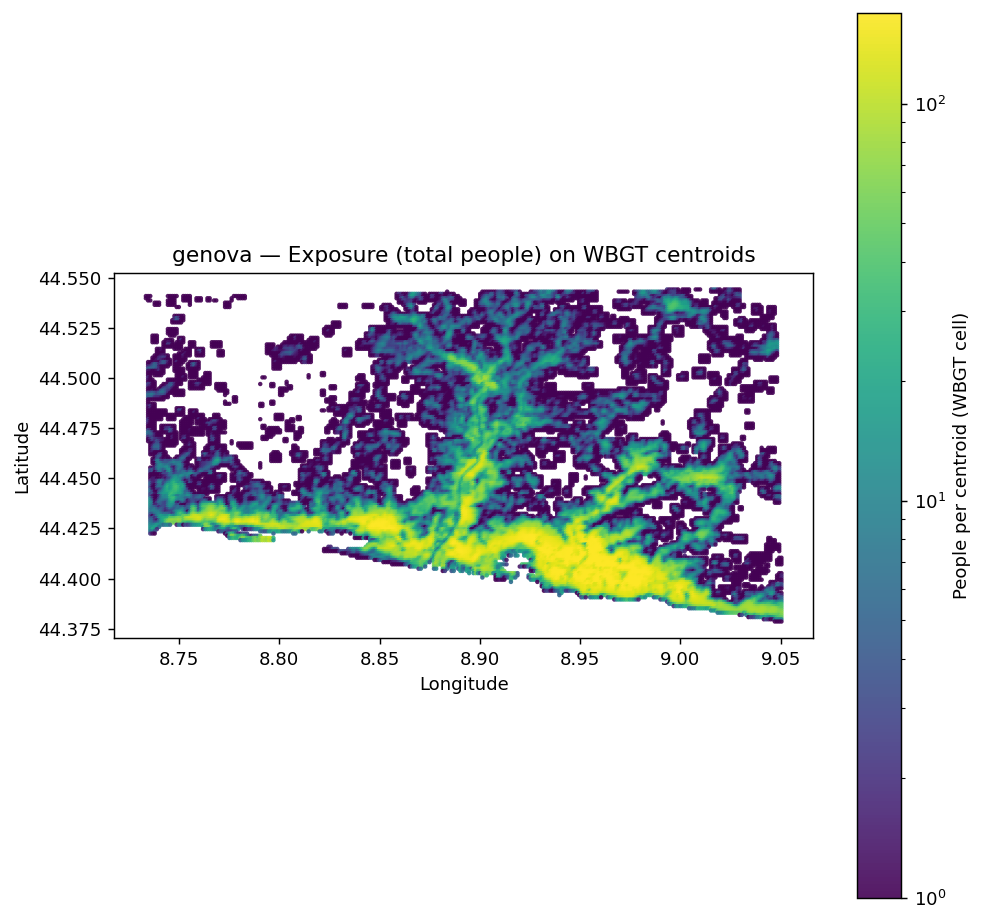

Exposure total (check): 573,935 people


In [24]:
# Building a GeoDataFrame stacking the 3 age rasters at centroids where pop>0 & inside CITY_MASK
haz_valid = CITY_MASK.ravel()
impf_id = {"<15": 1, "15-64": 2, "65+": 3}

frames = []
for grp, raster in age_on_ref.items():
    pop_flat = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid = haz_valid & (pop_flat > 0)
    if valid.any():
        frames.append(
            gpd.GeoDataFrame(
                {
                    "value": pop_flat[valid],
                    "longitude": lon[valid],
                    "latitude":  lat[valid],
                    "age_group": np.full(valid.sum(), grp, dtype=object),
                    "impf_HEAT": np.full(valid.sum(), impf_id[grp], dtype=int),
                },
                geometry=gpd.points_from_xy(lon[valid], lat[valid]),
                crs="EPSG:4326",
            )
        )

if frames:
    gdf = pd.concat(frames, ignore_index=True)
else:
    gdf = gpd.GeoDataFrame(columns=["value","longitude","latitude","age_group","impf_HEAT","geometry"], crs="EPSG:4326")

from climada.entity.exposures import Exposures
exp = Exposures()
exp.set_gdf(gdf)
exp.value_unit = "people"
exp.ref_year   = year
exp.tag = f"{CITY} FUA — WorldPop age groups ({year}) on WBGT grid"
exp.check()

print(exp)
if not exp.gdf.empty:
    print("Total people in exposure (WBGT grid):", float(exp.gdf["value"].sum()))
    print("Breakdown by age group (WBGT grid):")
    print(exp.gdf.groupby("age_group")["value"].sum().astype(float))

# map: total people per WBGT cell (log color)
from matplotlib.colors import LogNorm
vals_all  = np.nan_to_num(pop_on_ref, nan=0.0)
valid_all = CITY_MASK
vmax = np.nanpercentile(vals_all[valid_all], 99) if valid_all.any() else 1.0
norm = LogNorm(vmin=1, vmax=max(1.0, vmax))

plt.figure(figsize=(7.8, 7.2))
sc = plt.scatter(lon[valid_all.ravel()], lat[valid_all.ravel()],
                 c=vals_all.ravel()[valid_all.ravel()], s=6, linewidths=0, alpha=0.9, norm=norm)
cb = plt.colorbar(sc); cb.set_label("People per centroid (WBGT cell)")
plt.title(f"{CITY} — Exposure (total people) on WBGT centroids")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

print(f"Exposure total (check): {vals_all[valid_all].sum():,.0f} people")

**Save for future notebooks**

In [25]:
haz_path = INT / f"hazard_HEAT_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)

summary = pd.DataFrame({
    "event_id": H.event_id,
    "event_name": [f"HEAT_{y}" for y in years],
    "date": [str(d) for d in H.date],
    "frequency": H.frequency,
    "mean_intensity": np.asarray(I.mean(axis=1)).ravel(),
})
summary_path = INT / f"hazard_events_{SLUG}.csv"
summary.to_csv(summary_path, index=False)

print(f"Saved hazard → {haz_path}")
print(f"Saved exposure → {exp_path}")
print(f"Saved summary → {summary_path}")

2025-11-12 11:07:06,928 - climada.hazard.io - WARNING - write_hdf5: the class member event_name is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to event_name being set to its default value.
2025-11-12 11:07:06,928 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_HEAT_genova.h5
Saved exposure → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_people_genova.h5
Saved summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_events_genova.csv


In [26]:
years_arr = np.array(sorted(wbgt_hot_days.keys()), dtype=int)
stack = np.stack([wbgt_hot_days[y] for y in years_arr], axis=0)  # (n_years, HGT, WDT)

np.savez_compressed(INT / f"wbgt_hot_days_2030_2100_{SLUG}.npz", years=years_arr, data=stack)

print("Saved hot-days stack →", INT / "wbgt_hot_days_2030_2100.npz")

Saved hot-days stack → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/wbgt_hot_days_2030_2100.npz
